# Iterative Monte Carlo Scatter Correction with SIMIND and SIRF

This notebook demonstrates a reconstruction-driven Monte Carlo (MC) scatter-correction workflow for **Lu-177 SPECT**.

Rather than subtracting an estimated scatter distribution from the measured photopeak projections, scatter is incorporated into the statistical forward model as an additive term:

$$
E[y] = Ax + b,
$$

where \(Ax\) is the estimated primary contribution and \(b\) is the scatter estimate.

The workflow is iterative:

$$
x_0
\rightarrow
\mathrm{SIMIND}
\rightarrow
\hat{s}_{MC,1}
\rightarrow
x_1
\rightarrow
\mathrm{SIMIND}
\rightarrow
\hat{s}_{MC,2}
\rightarrow
x_2
\rightarrow \cdots
$$

The initial estimate \(x_0\) is obtained using the conventional TEW scatter estimate. Each subsequent reconstruction is then used as the activity estimate for the next SIMIND scatter simulation.

For this demonstration, three MC iterations are performed so that we can assess whether the reconstruction is stabilising.

## 1. Imports and configuration

The same simulated Lu-177 NEMA acquisition used in the first demonstration is used here. Resolution modelling is deliberately omitted so that the effect of the scatter-correction strategy can be examined independently.

In [16]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from scipy.special import erf

import sirf.STIR as spect

sys.path.insert(0, "/home/jovyan/sirf-demo/.packages")
from simind_python_connector import StirSimindAdaptor
import stir_simind_utils as utils

spect.set_verbosity(0)

demo1_path = Path("/home/jovyan/sirf-demo/SIRF-demo-1")
demo2_path = Path("/home/jovyan/sirf-demo/SIRF-demo-2")

sim_dir = demo1_path / "simind_data" / "lu177_128"
input_dir = sim_dir / "input"
tomo_dir = sim_dir / "tomo"

mc_dir = demo2_path / "mc_scatter"
mc_dir.mkdir(parents=True, exist_ok=True)

# Calibration factor derived independently from the cylindrical phantom simulation
icf = 109.264725

# Number of MC scatter-estimation/reconstruction cycles
n_mc_iterations = 3

# Smoothing applied to the activity estimate before SIMIND
source_smoothing_fwhm_mm = 9.0

# Smoothing applied to the MC scatter projections
scatter_smoothing_sigma = 2.0

# Final reconstruction settings
recon_subiterations = 100
recon_subsets = 2
save_interval = 10

## 2. Load the acquisition data

The noisy photopeak projections are retained as the measured data throughout the MC-corrected reconstruction.

The TEW scatter estimate is used only to generate the **initial activity estimate** \(x_0\). Subsequent MC-corrected reconstructions use the SIMIND scatter estimate as the additive term \(b\).

In [2]:
pp_path = tomo_dir / "lu177_simulation_em_noisy.hs"
tew_scatter_path = tomo_dir / "lu177_simulation_tew_scatter.hs"
attenuation_path = input_dir / "nema_lu_ctac.hv"
source_path = input_dir / "nema_lu_act.hv"

acq_em_data = spect.AcquisitionData(str(pp_path))
acq_tew_data = spect.AcquisitionData(str(tew_scatter_path))
attenuation_map = spect.ImageData(str(attenuation_path))
known_source = spect.ImageData(str(source_path))

matrix_size = (128,) * 3
voxel_size = (4.42,) * 3

initial_image = spect.ImageData(acq_em_data)
initial_image.initialise(matrix_size, vsize=voxel_size)
initial_image.set_modality("NM")
initial_image.fill(1)

# Dataset-specific orientation required by the STIR attenuation model
attenuation_map_stir = attenuation_map.clone()
attenuation_map_stir.fill(
    np.flip(attenuation_map.as_array(), axis=2)
)

## 3. Generate the initial activity estimate

The initial reconstruction uses the TEW scatter estimate as the additive term:

$$
E[y] = Ax + \hat{s}_{TEW}.
$$

This reconstruction is not the final result. Its purpose is to provide a physically plausible first estimate of the activity distribution for the SIMIND simulation.

The initial reconstruction uses 60 subiterations and 12 subsets.

In [3]:
def make_acquisition_model(additive_term):
    matrix = spect.SPECTUBMatrix()
    matrix.set_keep_all_views_in_cache(True)
    matrix.set_attenuation_image(attenuation_map_stir)

    model = spect.AcquisitionModelUsingMatrix(matrix)
    model.set_additive_term(additive_term)
    model.set_up(acq_em_data, initial_image)

    return model


initial_model = make_acquisition_model(acq_tew_data)

objective_function = spect.make_Poisson_loglikelihood(acq_em_data)
objective_function.set_acquisition_model(initial_model)

initial_reconstructor = spect.OSMAPOSLReconstructor()
initial_reconstructor.set_num_subiterations(60)
initial_reconstructor.set_num_subsets(12)
initial_reconstructor.set_objective_function(objective_function)

initial_reconstruction_counts = initial_image.clone()
initial_reconstructor.set_up(initial_reconstruction_counts)
initial_reconstructor.reconstruct(initial_reconstruction_counts)

initial_reconstruction_counts.write(
    str(mc_dir / "initial_tew_reconstruction")
)

# Convert reconstructed counts to activity using the independently derived ICF
initial_reconstruction = initial_reconstruction_counts / icf

### Prepare the activity estimate for SIMIND

The reconstructed activity image is smoothed before being used as the SIMIND source distribution. The aim is to suppress reconstruction noise that would otherwise be propagated into the Monte Carlo scatter estimate.

The smoothing applied here is **9 mm FWHM**.

(<Figure size 1800x500 with 6 Axes>,
 array([<Axes: title={'center': 'Initial TEW reconstruction'}>,
        <Axes: title={'center': 'Smoothed source for SIMIND'}>,
        <Axes: title={'center': 'Known source distribution'}>],
       dtype=object))

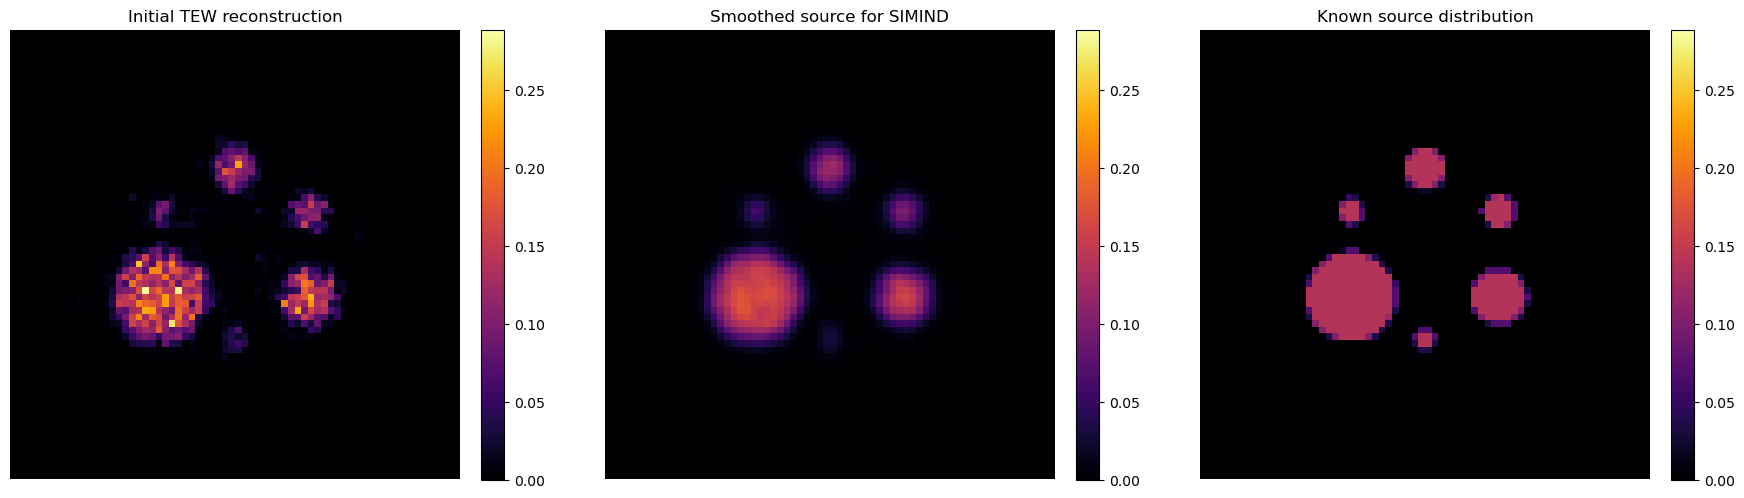

In [4]:
def prepare_simind_source(reconstruction):
    source = reconstruction.clone()

    gaussian_filter = spect.SeparableGaussianImageFilter()
    gaussian_filter.set_fwhms(
        (source_smoothing_fwhm_mm,) * 3
    )
    gaussian_filter.apply(source)

    return source


source_for_simind = prepare_simind_source(initial_reconstruction)

idx = (55, slice(30, 98), slice(30, 98))

vmax = max(
    np.max(initial_reconstruction.as_array()[idx]),
    np.max(source_for_simind.as_array()[idx]),
    np.max(known_source.as_array()[idx]),
)

utils.display_arr(
    arr_3d=[
        initial_reconstruction.as_array(),
        source_for_simind.as_array(),
        known_source.as_array(),
    ],
    idx=idx,
    vmax=[vmax] * 3,
    titles=[
        "Initial TEW reconstruction",
        "Smoothed source for SIMIND",
        "Known source distribution",
    ],
    cmap=["inferno"] * 3,
)

## 4. Monte Carlo scatter estimation

For each MC iteration:

1. the current reconstructed activity estimate is smoothed;
2. SIMIND generates total and scatter-only projections;
3. the MC projections are globally normalised to the measured photopeak data;
4. the scaled scatter estimate is smoothed;
5. the scatter estimate is used as the additive term in a new OSEM reconstruction.

### Global normalisation

A single global scale factor is used:

$$
\beta =
\frac{\sum_i y_i}
     {\sum_i y^{MC}_i},
$$

where \(y\) is the measured photopeak acquisition and \(y^{MC}\) is the total SIMIND photopeak simulation.

The MC scatter estimate is then

$$
\hat{s}_{MC} = \beta\,s_{MC}.
$$

Using a single factor preserves the relative spatial and angular distribution of scatter predicted by SIMIND.

In [5]:
# SIMIND configuration
window_lower = [187.2]   # keV
window_upper = [228.8]   # keV
scatter_orders = [0]
time_per_projection = 10  # s

config_file = "/home/jovyan/sirf-demo/.packages/Discovery670_lu177.yaml"


def simulate_mc_scatter(source_image, iteration):
    output_dir = mc_dir / f"simind_data_it{iteration}"
    output_dir.mkdir(parents=True, exist_ok=True)

    prefix = "lu177_mc_scatter"

    simind = StirSimindAdaptor(
        config_source=str(config_file),
        output_dir=str(output_dir),
        output_prefix=prefix,
        photon_multiplier=0.05,
    )

    simind.set_source(source_image)
    simind.set_mu_map(attenuation_map)

    # Activity × projection duration
    simind.add_config_value(
        25,
        np.sum(source_image.as_array()) * time_per_projection,
    )

    simind.set_energy_windows(
        lower_bounds=window_lower,
        upper_bounds=window_upper,
        scatter_orders=scatter_orders,
    )

    simind.add_runtime_switch("FI", "lu177")
    simind.add_runtime_switch("CC", "ge-megp")
    simind.add_runtime_switch("RR", 12345)

    simind.run()

    simulated_total = spect.AcquisitionData(
        str(output_dir / f"{prefix}_tot_w1.hs")
    )
    simulated_scatter = spect.AcquisitionData(
        str(output_dir / f"{prefix}_sca_w1.hs")
    )

    # Global normalisation of the SIMIND projection data
    beta = (
        acq_em_data.as_array().sum()
        / simulated_total.as_array().sum()
    )

    scaled_scatter = simulated_scatter.clone()
    scaled_scatter.fill(
        simulated_scatter.as_array() * beta
    )

    smoothed_scatter = utils.smooth_acquisition_data(
        acq_data=scaled_scatter,
        sigma=scatter_smoothing_sigma,
    )

    return smoothed_scatter, beta

## 5. Reconstruct with the MC scatter estimate

Each MC scatter estimate is incorporated directly into the forward model as the additive term. The reconstruction is run for 100 subiterations with 2 subsets, saving an image every 10 subiterations.

The converged reconstruction from each MC cycle becomes the activity estimate for the next cycle.

In [6]:
def reconstruct_with_scatter(scatter_estimate, iteration):
    recon_dir = mc_dir / "recons" / f"osem_mc{iteration}"
    recon_dir.mkdir(parents=True, exist_ok=True)

    acquisition_model = make_acquisition_model(scatter_estimate)

    objective_function = spect.make_Poisson_loglikelihood(acq_em_data)
    objective_function.set_acquisition_model(acquisition_model)

    reconstructor = spect.OSMAPOSLReconstructor()
    reconstructor.set_num_subiterations(recon_subiterations)
    reconstructor.set_num_subsets(recon_subsets)
    reconstructor.set_save_interval(save_interval)
    reconstructor.enable_output()
    reconstructor.set_output_filename_prefix(
        str(recon_dir / "lu177_mc_recon")
    )
    reconstructor.set_objective_function(objective_function)

    reconstruction = initial_image.clone()
    reconstructor.set_up(reconstruction)
    reconstructor.reconstruct(reconstruction)

    return reconstruction, recon_dir

## 6. Run the iterative MC correction

The loop below performs three complete MC scatter-estimation/reconstruction cycles.

The activity estimate passed to SIMIND is updated after every cycle:

$$
x_k \rightarrow \hat{s}_{MC,k+1} \rightarrow x_{k+1}.
$$

The reconstruction stored in `mc_reconstructions[k]` is calibrated to activity, while the corresponding scatter estimate is retained in `mc_scatter_estimates[k]`.

In [7]:
mc_reconstructions = {}
mc_scatter_estimates = {}
mc_scale_factors = {}
mc_recon_dirs = {}

current_reconstruction = initial_reconstruction

for iteration in range(1, n_mc_iterations + 1):
    print(f"MC iteration {iteration}/{n_mc_iterations}")

    source_for_simind = prepare_simind_source(
        current_reconstruction
    )

    scatter_estimate, beta = simulate_mc_scatter(
        source_image=source_for_simind,
        iteration=iteration,
    )

    reconstruction_counts, recon_dir = reconstruct_with_scatter(
        scatter_estimate=scatter_estimate,
        iteration=iteration,
    )

    reconstruction = reconstruction_counts / icf

    mc_scatter_estimates[iteration] = scatter_estimate
    mc_reconstructions[iteration] = reconstruction
    mc_scale_factors[iteration] = beta
    mc_recon_dirs[iteration] = recon_dir

    # The new reconstruction becomes the source estimate
    # for the next MC iteration.
    current_reconstruction = reconstruction

MC iteration 1/3


INFO: Running SIMIND: simind lu177_mc_scatter lu177_mc_scatter /NN:0.05/FI:lu177/CC:ge-megp/RR:12345/PX:0.4420000076293945


 



              SIMIND Monte Carlo Simulation Program    V8.0  
------------------------------------------------------------------------------
 Phantom S : h2o       Crystal...: nai       InputFile.: lu177_mc_scatter  
 Phantom B : bone      BackScatt.: pmt       OutputFile: lu177_mc_scatter  
 Collimator: pb_sb2    SourceRout: smap      SourceImg.: lu177_mc_scatter_s
 Cover.....: al        ScoreRout.: scattwin  DensityImg: lu177_mc_scatter_d
------------------------------------------------------------------------------
 PhotonEnergy.......: 208          lu177     PhotonsPerProj....: 41370          
 EnergyResolution...: 12           Spectra   Activity..........: 2957.5         
 MaxScatterOrder....: 3            ge-megp   DetectorLenght....: 20             
 DetectorWidth......: 27           SPECT     DetectorHeight....: 0.9525         
 UpperEneWindowTresh: 312          x-rays    Distance to det...: 17.022         
 LowerEneWindowTresh: 104          Random    ShiftSource X.....: 0

INFO: Converted 120 radii from orbit file lu177_mc_scatter.cor
INFO: Successfully converted /home/jovyan/sirf-demo/SIRF-demo-2/mc_scatter/simind_data_it1/lu177_mc_scatter_air_w1.h00 to /home/jovyan/sirf-demo/SIRF-demo-2/mc_scatter/simind_data_it1/lu177_mc_scatter_air_w1.hs
INFO: Converted 120 radii from orbit file lu177_mc_scatter.cor
INFO: Successfully converted /home/jovyan/sirf-demo/SIRF-demo-2/mc_scatter/simind_data_it1/lu177_mc_scatter_sca_w1.h00 to /home/jovyan/sirf-demo/SIRF-demo-2/mc_scatter/simind_data_it1/lu177_mc_scatter_sca_w1.hs
INFO: Converted 120 radii from orbit file lu177_mc_scatter.cor
INFO: Successfully converted /home/jovyan/sirf-demo/SIRF-demo-2/mc_scatter/simind_data_it1/lu177_mc_scatter_sca_w2.h00 to /home/jovyan/sirf-demo/SIRF-demo-2/mc_scatter/simind_data_it1/lu177_mc_scatter_sca_w2.hs
INFO: Converted 120 radii from orbit file lu177_mc_scatter.cor
INFO: Successfully converted /home/jovyan/sirf-demo/SIRF-demo-2/mc_scatter/simind_data_it1/lu177_mc_scatter_tot_w1.

------------------------------------------------------------------------------
 GENERAL DATA
 keV/channel........: 1                      CutoffEnergy......: 0              
 Photons/Bq.........: 0.2264                 StartingAngle.....: 0              
 CameraOffset X.....: 0                      CoverThickness....: 0.1            
 CameraOffset Y.....: 0                      BackscatterThickn.: 0              
 MatrixSize I.......: 128                    IntrinsicResolut..: 0.55           
 MatrixSize J.......: 128                    AcceptanceAngle...: 4.02754        
 Emission type......: 2                      Initial Weight....: 16184.96701    
 NN ScalingFactor...: 0.05                   Energy Channels...: 512            
                                                                              
 SPECT DATA
 RotationMode.......: 360                    Nr of Projections.: 120            
 RotationAngle......: 3                      Projection.[start]: 1              
 Orbit

...

MC iteration 3/3


INFO: Running SIMIND: simind lu177_mc_scatter lu177_mc_scatter /NN:0.05/FI:lu177/CC:ge-megp/RR:12345/PX:0.4420000076293945


 



              SIMIND Monte Carlo Simulation Program    V8.0  
------------------------------------------------------------------------------
 Phantom S : h2o       Crystal...: nai       InputFile.: lu177_mc_scatter  
 Phantom B : bone      BackScatt.: pmt       OutputFile: lu177_mc_scatter  
 Collimator: pb_sb2    SourceRout: smap      SourceImg.: lu177_mc_scatter_s
 Cover.....: al        ScoreRout.: scattwin  DensityImg: lu177_mc_scatter_d
------------------------------------------------------------------------------
 PhotonEnergy.......: 208          lu177     PhotonsPerProj....: 42985          
 EnergyResolution...: 12           Spectra   Activity..........: 2929.5         
 MaxScatterOrder....: 3            ge-megp   DetectorLenght....: 20             
 DetectorWidth......: 27           SPECT     DetectorHeight....: 0.9525         
 UpperEneWindowTresh: 312          x-rays    Distance to det...: 17.022         
 LowerEneWindowTresh: 104          Random    ShiftSource X.....: 0

INFO: Converted 120 radii from orbit file lu177_mc_scatter.cor
INFO: Successfully converted /home/jovyan/sirf-demo/SIRF-demo-2/mc_scatter/simind_data_it3/lu177_mc_scatter_air_w1.h00 to /home/jovyan/sirf-demo/SIRF-demo-2/mc_scatter/simind_data_it3/lu177_mc_scatter_air_w1.hs
INFO: Converted 120 radii from orbit file lu177_mc_scatter.cor
INFO: Successfully converted /home/jovyan/sirf-demo/SIRF-demo-2/mc_scatter/simind_data_it3/lu177_mc_scatter_sca_w1.h00 to /home/jovyan/sirf-demo/SIRF-demo-2/mc_scatter/simind_data_it3/lu177_mc_scatter_sca_w1.hs
INFO: Converted 120 radii from orbit file lu177_mc_scatter.cor
INFO: Successfully converted /home/jovyan/sirf-demo/SIRF-demo-2/mc_scatter/simind_data_it3/lu177_mc_scatter_sca_w2.h00 to /home/jovyan/sirf-demo/SIRF-demo-2/mc_scatter/simind_data_it3/lu177_mc_scatter_sca_w2.hs
INFO: Converted 120 radii from orbit file lu177_mc_scatter.cor
INFO: Successfully converted /home/jovyan/sirf-demo/SIRF-demo-2/mc_scatter/simind_data_it3/lu177_mc_scatter_tot_w1.

------------------------------------------------------------------------------
 GENERAL DATA
 keV/channel........: 1                      CutoffEnergy......: 0              
 Photons/Bq.........: 0.2264                 StartingAngle.....: 0              
 CameraOffset X.....: 0                      CoverThickness....: 0.1            
 CameraOffset Y.....: 0                      BackscatterThickn.: 0              
 MatrixSize I.......: 128                    IntrinsicResolut..: 0.55           
 MatrixSize J.......: 128                    AcceptanceAngle...: 4.02754        
 Emission type......: 2                      Initial Weight....: 15429.40423    
 NN ScalingFactor...: 0.05                   Energy Channels...: 512            
                                                                              
 SPECT DATA
 RotationMode.......: 360                    Nr of Projections.: 120            
 RotationAngle......: 3                      Projection.[start]: 1              
 Orbit

## 7. Evolution of the MC scatter estimate

The scatter projections from successive MC iterations can be inspected directly. This allows us to see whether updating the activity estimate materially changes the spatial distribution of the estimated scatter.

No scatter-fraction metric is required for this comparison.

(<Figure size 1800x500 with 6 Axes>,
 array([<Axes: title={'center': 'MC scatter iteration 1'}>,
        <Axes: title={'center': 'MC scatter iteration 2'}>,
        <Axes: title={'center': 'MC scatter iteration 3'}>], dtype=object))

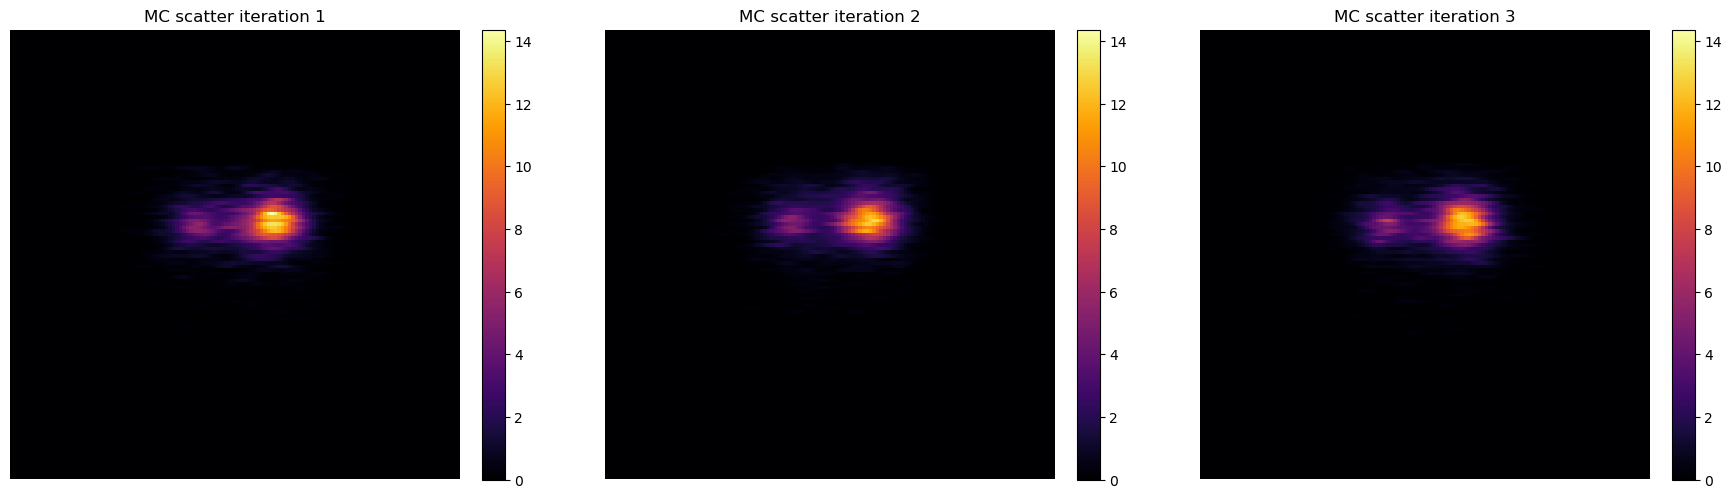

In [8]:
scatter_arrays = [
    mc_scatter_estimates[it].as_array()[0]
    for it in range(1, n_mc_iterations + 1)
]

scatter_vmax = max(
    np.max(arr[:, 60, :])
    for arr in scatter_arrays
)

utils.display_arr(
    arr_3d=scatter_arrays,
    idx=(slice(None), 60, slice(None)),
    vmax=[scatter_vmax] * n_mc_iterations,
    titles=[
        f"MC scatter iteration {it}"
        for it in range(1, n_mc_iterations + 1)
    ],
    cmap=["inferno"] * n_mc_iterations,
)

## 8. Evolution of the reconstructed activity distribution

The initial TEW reconstruction and the three MC-corrected reconstructions are displayed using a common intensity scale.

This provides a direct visual indication of how much the reconstructed activity distribution changes as the MC scatter estimate is updated.

(<Figure size 2400x500 with 8 Axes>,
 array([<Axes: title={'center': 'Initial TEW'}>,
        <Axes: title={'center': 'MC iteration 1'}>,
        <Axes: title={'center': 'MC iteration 2'}>,
        <Axes: title={'center': 'MC iteration 3'}>], dtype=object))

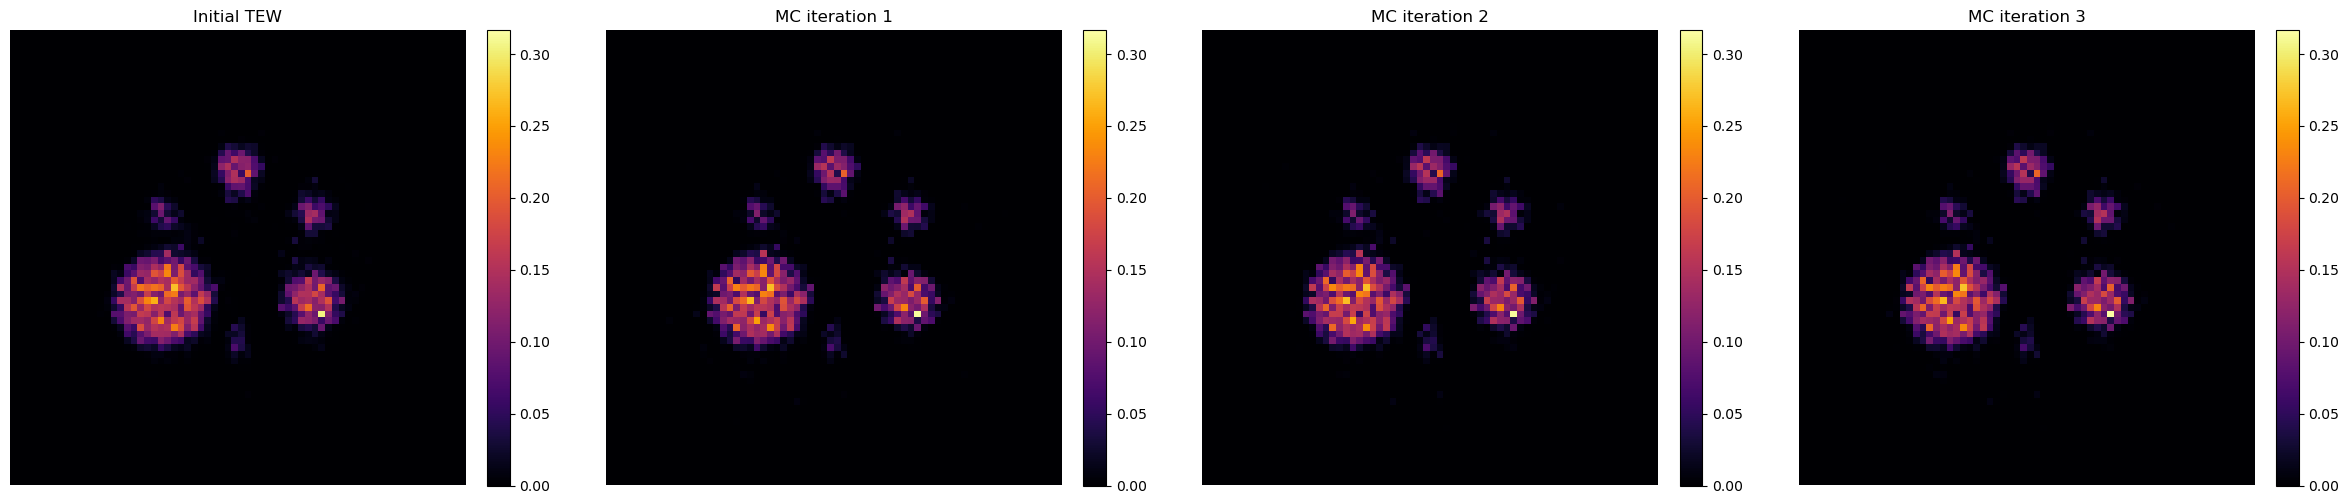

In [9]:
idx = (56, slice(30, 98), slice(30, 98))

reconstruction_arrays = [
    initial_reconstruction.as_array(),
    *[
        mc_reconstructions[it].as_array()
        for it in range(1, n_mc_iterations + 1)
    ],
]

reconstruction_titles = [
    "Initial TEW",
    *[
        f"MC iteration {it}"
        for it in range(1, n_mc_iterations + 1)
    ],
]

vmax = max(
    np.max(arr[idx])
    for arr in reconstruction_arrays
)

utils.display_arr(
    arr_3d=reconstruction_arrays,
    idx=idx,
    vmax=[vmax] * len(reconstruction_arrays),
    titles=reconstruction_titles,
    cmap=["inferno"] * len(reconstruction_arrays),
)

## 9. Reconstruction convergence between MC iterations

A simple image-domain change metric is used to quantify how much each MC-corrected reconstruction changes relative to the previous estimate:

$$
\Delta_k =
\frac{\lVert x_k-x_{k-1}\rVert_1}
     {\lVert x_{k-1}\rVert_1}.
$$

This is not an image-quality metric. It is used only to assess whether additional MC iterations are continuing to change the reconstruction substantially.

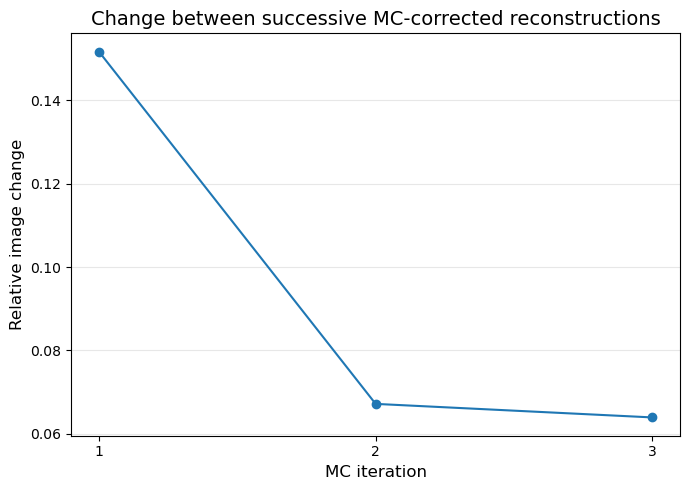

In [10]:
previous = initial_reconstruction.as_array()
relative_changes = []

for iteration in range(1, n_mc_iterations + 1):
    current = mc_reconstructions[iteration].as_array()

    relative_change = (
        np.sum(np.abs(current - previous))
        / np.sum(np.abs(previous))
    )

    relative_changes.append(relative_change)
    previous = current

plt.figure(figsize=(7, 5))
plt.plot(
    range(1, n_mc_iterations + 1),
    relative_changes,
    marker="o",
)
plt.xticks(range(1, n_mc_iterations + 1))
plt.xlabel("MC iteration", fontsize=12)
plt.ylabel("Relative image change", fontsize=12)
plt.title("Change between successive MC-corrected reconstructions", fontsize=14)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Quantitative evaluation using recovery coefficients

Because the digital NEMA source distribution is known, recovery coefficients can be used to assess whether repeated MC scatter estimation changes quantitative recovery.

The comparison below uses:

- the conventional TEW reconstruction at 100 subiterations; and
- the 100-subiteration reconstruction from each MC iteration.

The same independently derived Lu-177 ICF is used for every reconstruction.

In [12]:
sphere_diameters_mm = [13, 17, 22, 28, 37, 60]

gt_dir = input_dir
known_source_array = known_source.as_array()
masks_dict = dict(np.load(gt_dir / "masks_lu.npz"))

# Conventional TEW reconstruction from Demo 1
tew_recon_path = (
    demo1_path
    / "simind_data"
    / "lu177_128"
    / "recons"
    / "osem"
    / "lu177_sim_osem_100.hv"
)
tew_reconstruction = (
    spect.ImageData(str(tew_recon_path)).as_array()
    / icf
)


def recovery_coefficients_for_image(reconstruction):
    rc = []

    for sphere_number in range(1, 7):
        mask = masks_dict[f"sphere_{sphere_number}"]
        source_mean = np.mean(
            known_source_array[mask > 0]
        )
        recon_mean = np.mean(
            reconstruction[mask > 0]
        )
        rc.append(recon_mean / source_mean)

    return np.asarray(rc)


rc_by_method = {
    "TEW": recovery_coefficients_for_image(
        tew_reconstruction
    )
}

for iteration in range(1, n_mc_iterations + 1):
    rc_by_method[f"MC {iteration}"] = (
        recovery_coefficients_for_image(
            mc_reconstructions[iteration].as_array()
        )
    )

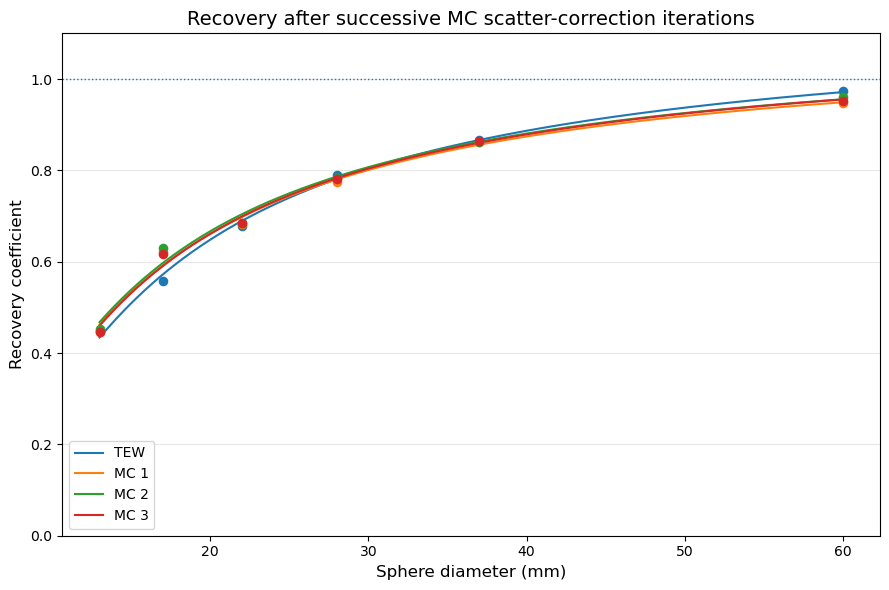

  TEW: A = 1.144, sigma = 3.80 mm, FWHM = 8.96 mm
 MC 1: A = 1.102, sigma = 3.48 mm, FWHM = 8.21 mm
 MC 2: A = 1.108, sigma = 3.47 mm, FWHM = 8.17 mm
 MC 3: A = 1.111, sigma = 3.53 mm, FWHM = 8.31 mm


In [17]:
def gaussian_sphere_recovery(diameter_mm, amplitude, sigma_mm):
    """
    Mean recovery in the true volume of a uniform sphere after convolution
    with an isotropic 3D Gaussian PSF.

    Parameters
    ----------
    diameter_mm : array-like
        Sphere diameter in mm.
    amplitude : float
        Asymptotic large-object recovery.
    sigma_mm : float
        Gaussian PSF sigma in mm.
    """
    diameter_mm = np.asarray(diameter_mm, dtype=float)
    radius = diameter_mm / 2.0

    term1 = erf(np.sqrt(2.0) * radius / sigma_mm)

    term2 = (
        np.sqrt(2.0 / np.pi)
        * sigma_mm
        * (3.0 * radius**2 - sigma_mm**2)
        / (2.0 * radius**3)
    )

    term3 = (
        np.sqrt(2.0 / np.pi)
        * sigma_mm
        * (radius**2 - sigma_mm**2)
        / (2.0 * radius**3)
        * np.exp(-2.0 * radius**2 / sigma_mm**2)
    )

    return amplitude * (term1 - term2 + term3)


diameter_smooth = np.linspace(
    min(sphere_diameters_mm),
    max(sphere_diameters_mm),
    500,
)

plt.figure(figsize=(9, 6))

fit_parameters = {}

for method, rc_values in rc_by_method.items():
    popt, _ = curve_fit(
        gaussian_sphere_recovery,
        sphere_diameters_mm,
        rc_values,
        p0=(1.0, 7.0),
        bounds=([0.0, 0.1], [2.0, 50.0]),
        maxfev=10000,
    )

    amplitude_fit, sigma_fit = popt
    fwhm_fit = 2.355 * sigma_fit

    fit_parameters[method] = {
        "amplitude": amplitude_fit,
        "sigma_mm": sigma_fit,
        "fwhm_mm": fwhm_fit,
    }

    rc_fit = gaussian_sphere_recovery(
        diameter_smooth,
        amplitude_fit,
        sigma_fit,
    )

    line, = plt.plot(
        diameter_smooth,
        rc_fit,
        label=method,
    )

    plt.scatter(
        sphere_diameters_mm,
        rc_values,
        color=line.get_color(),
        s=35,
        zorder=3,
    )

plt.axhline(1.0, linestyle=":", linewidth=1)
plt.xlabel("Sphere diameter (mm)", fontsize=12)
plt.ylabel("Recovery coefficient", fontsize=12)
plt.title(
    "Recovery after successive MC scatter-correction iterations",
    fontsize=14,
)
plt.ylim(0, 1.1)
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

for method, pars in fit_parameters.items():
    print(
        f"{method:>5s}: "
        f"A = {pars['amplitude']:.3f}, "
        f"sigma = {pars['sigma_mm']:.2f} mm, "
        f"FWHM = {pars['fwhm_mm']:.2f} mm"
    )

## 11. Final reconstruction compared with the known source

The final MC-corrected reconstruction is compared directly with the known digital activity distribution.

The difference image uses a symmetric colour scale around zero.

(<Figure size 1800x500 with 6 Axes>,
 array([<Axes: title={'center': 'Known source distribution'}>,
        <Axes: title={'center': 'MC-corrected reconstruction — iteration 3'}>,
        <Axes: title={'center': 'Reconstruction − known source'}>],
       dtype=object))

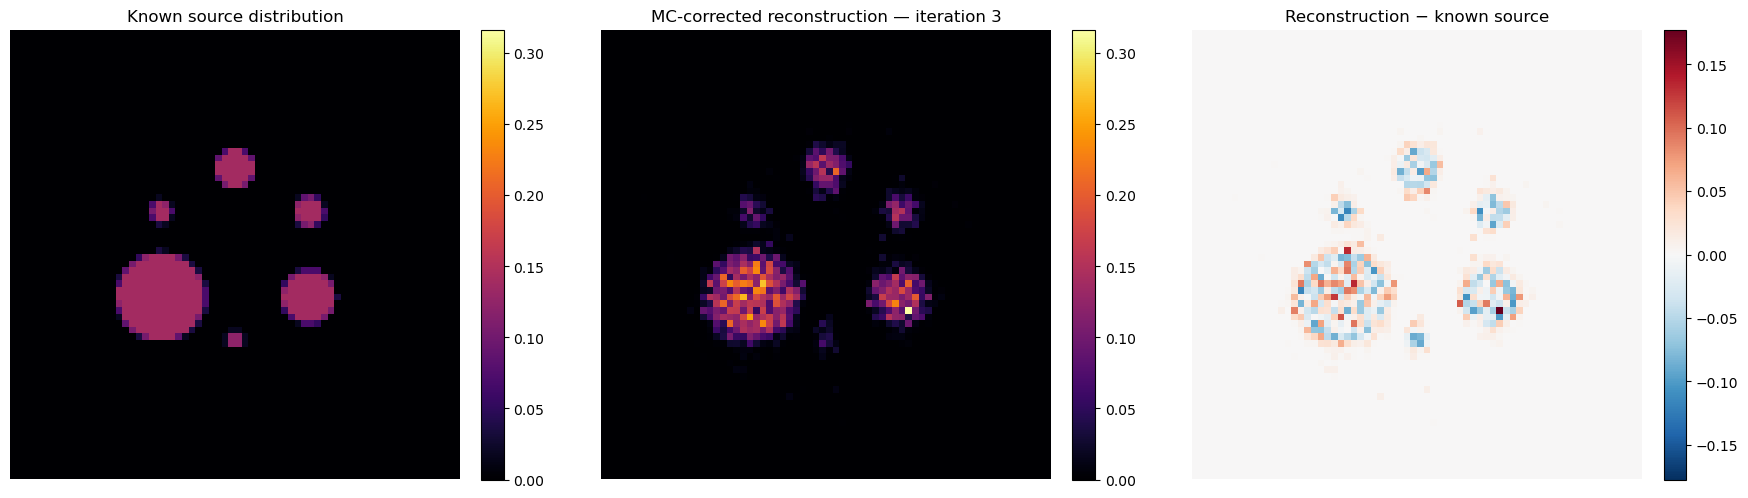

In [14]:
final_reconstruction = mc_reconstructions[
    n_mc_iterations
].as_array()

difference = final_reconstruction - known_source_array

idx = (56, slice(30, 98), slice(30, 98))

vmax = max(
    np.max(known_source_array[idx]),
    np.max(final_reconstruction[idx]),
)
diff_max = np.max(np.abs(difference[idx]))

utils.display_arr(
    arr_3d=[
        known_source_array,
        final_reconstruction,
        difference,
    ],
    idx=idx,
    vmin=[0, 0, -diff_max],
    vmax=[vmax, vmax, diff_max],
    titles=[
        "Known source distribution",
        f"MC-corrected reconstruction — iteration {n_mc_iterations}",
        "Reconstruction − known source",
    ],
    cmap=["inferno", "inferno", "RdBu_r"],
)

## Conclusions

- Monte Carlo scatter can be incorporated directly into the SPECT forward model as an **additive term**, rather than being subtracted from the measured photopeak projections.
- An initial TEW-based reconstruction provides the first activity estimate for SIMIND.
- The MC scatter estimate is **globally normalised** to the measured photopeak acquisition and smoothed before reconstruction.
- Updating the reconstructed activity distribution allows the MC scatter estimate to be refined iteratively.
- The image-change and recovery-coefficient analyses provide practical ways to determine whether additional MC iterations materially alter the reconstruction.
- Three MC iterations are used here for evaluation; the results can be used to decide whether fewer iterations are sufficient for the workshop demonstration.